In [65]:
import os
from pathlib import Path
from data_loader import load_prices, load_storage, load_efficiency, load_plant_capacity, load_demand
from gurobipy import Model, GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [66]:
current_dir = Path().resolve()
output_path = os.path.join(current_dir.parent, "results/model3")
figures_path = os.path.join(current_dir.parent, "results/figures")

storage_file = os.path.join(current_dir.parent, "data", "storage.csv")
storage = load_storage(storage_file)

print(storage)

{'coal': 864000, 'gas': 2592000, 'oil': 864000}


{'Coal': 864000, 'Gas': 2592000, 'Oil': 864000}


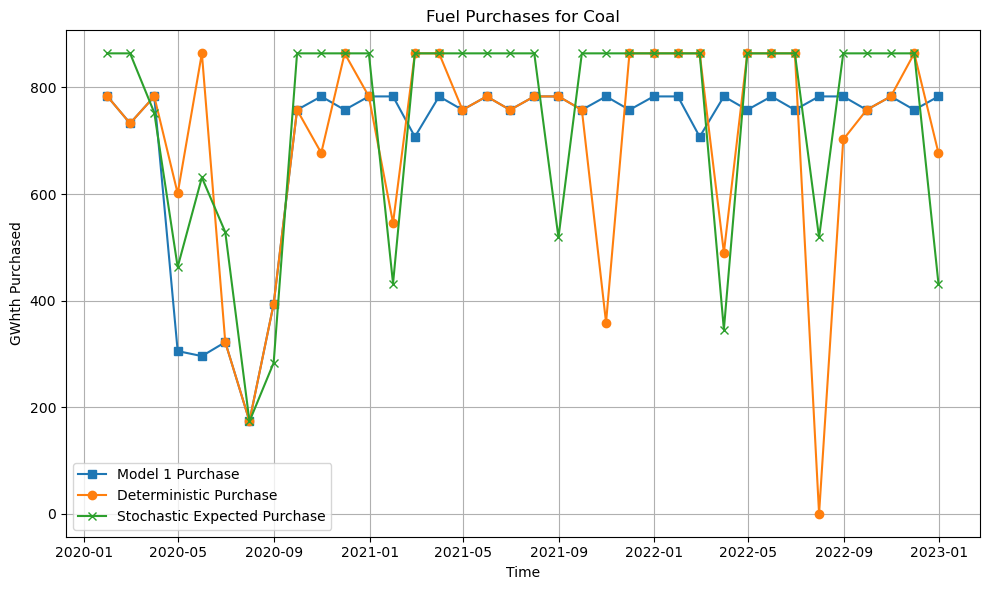

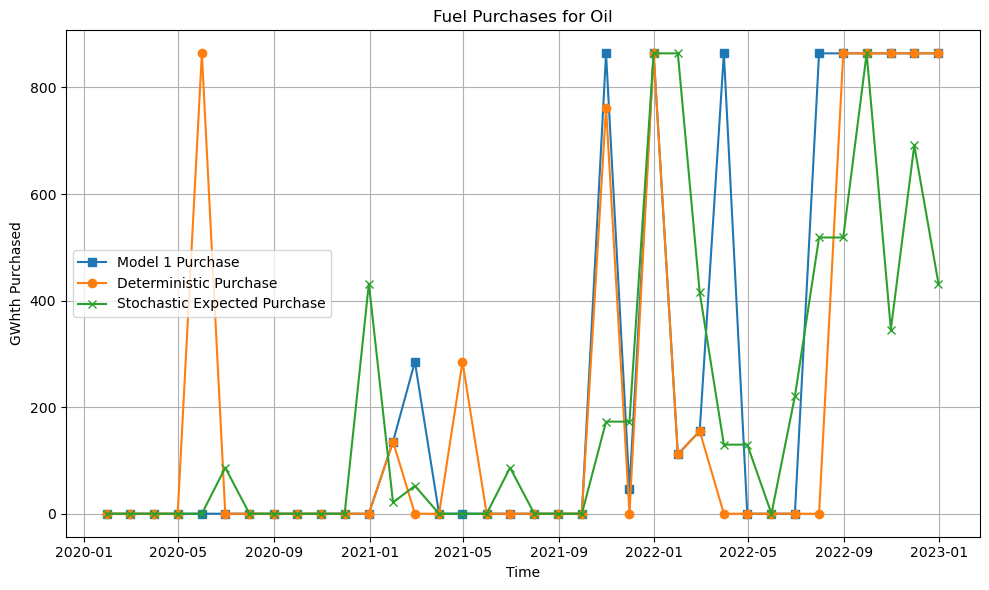

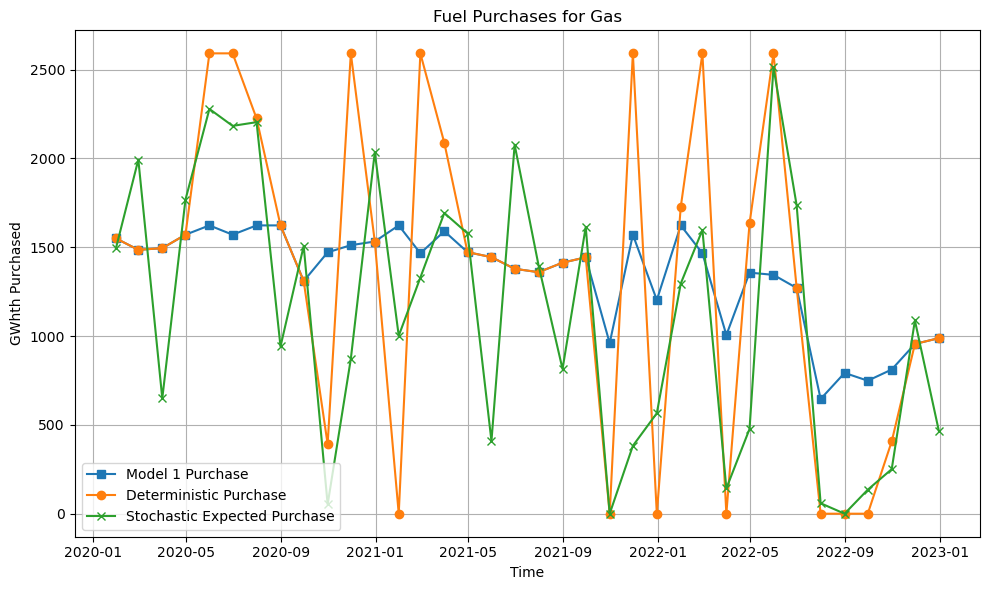

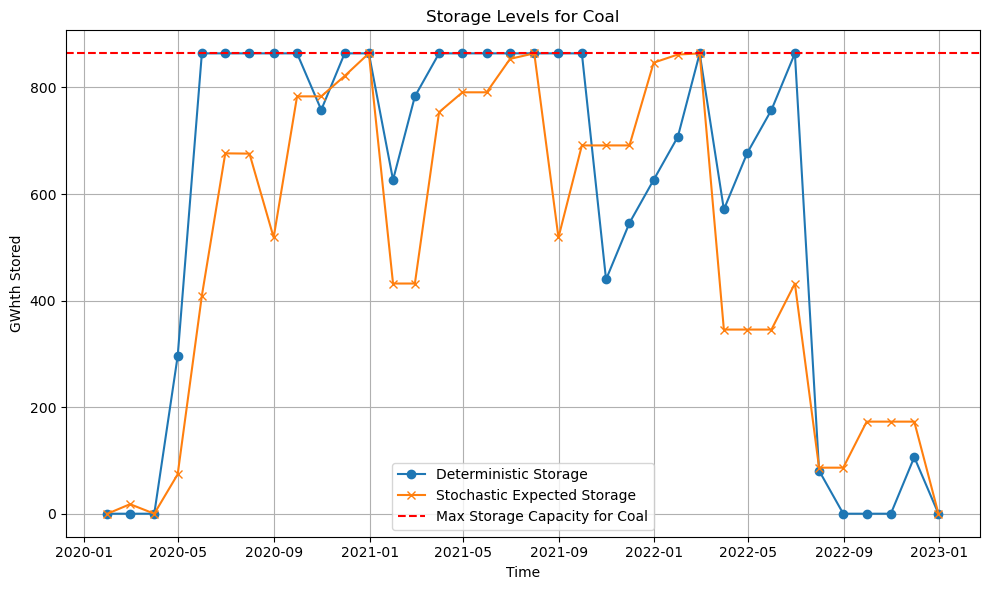

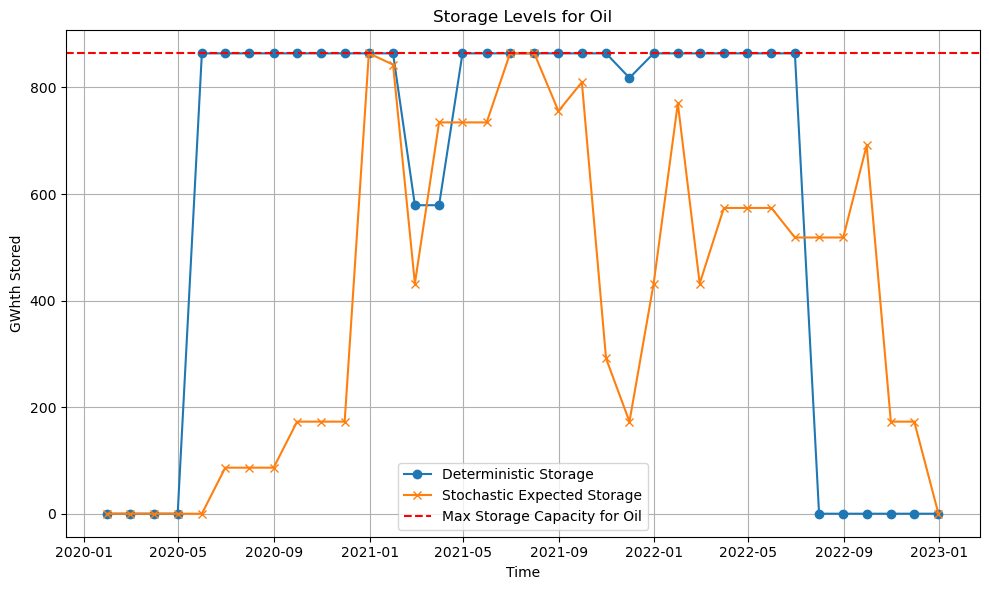

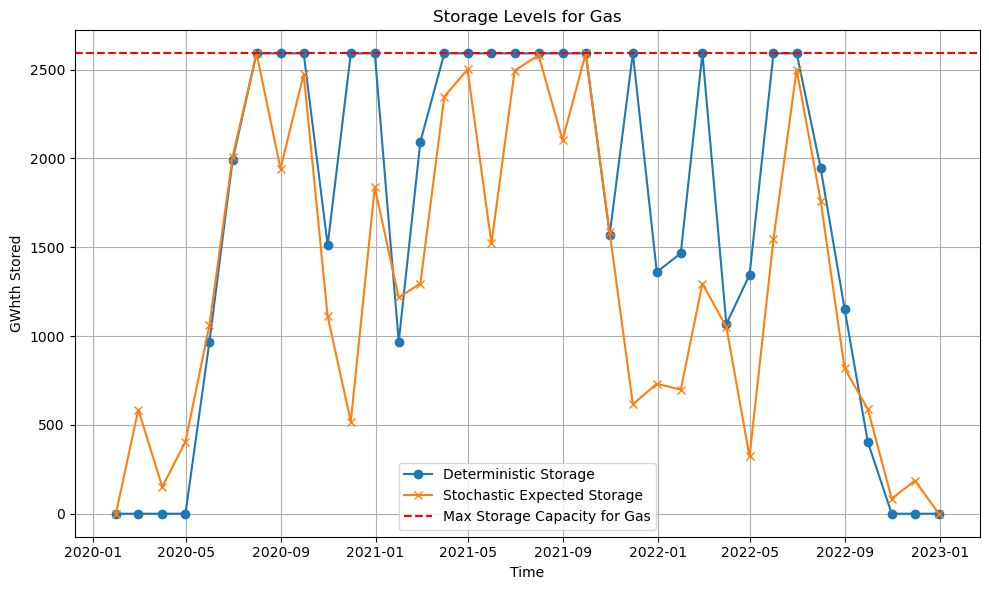

In [67]:

# Read in the proper DataFrames  for plotting (based on running-cost CSVs)
base_df = pd.read_csv(os.path.join(current_dir.parent, "results", "model1", "model1_results.csv"), parse_dates=["Month"], index_col="Month")
det_df = pd.read_csv(os.path.join(output_path, "deterministic_running_costs.csv"), parse_dates=["Month"], index_col="Month")
exp_df = pd.read_csv(os.path.join(output_path, "stochastic_expected_running_costs.csv"), parse_dates=["Month"], index_col="Month")

F = ['Coal', 'Oil', 'Gas']

name_mapping = {'coal':'Coal',
                'oil': 'Oil',
                'gas': 'Gas'}

# Map storage keys to capitalized names using name_mapping
storage_mapped = {name_mapping[k]: v for k, v in storage.items()}

print(storage_mapped)



def plot_fuel_purchases(base_df, det_df, exp_df, F):
    
    # plot deterministic vs stochastic expected purchases for each fuel
    for f in F:
        plt.figure(figsize=(10, 6))
        plt.plot(base_df.index, base_df[f"{f}_Bought"] / 1000, label='Model 1 Purchase', marker='s')
        plt.plot(det_df.index, det_df[f"{f}_Bought"] / 1000, label='Deterministic Purchase', marker='o')
        plt.plot(exp_df.index, exp_df[f"{f}_Bought"] / 1000, label='Stochastic Expected Purchase', marker='x')
        plt.title(f'Fuel Purchases for {f.capitalize()}')
        plt.xlabel('Time')
        plt.ylabel('GWhth Purchased')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_fuel_purchases(base_df, det_df, exp_df, F)

def plot_storage_levels(F, det_df, exp_df):
    
    for f in F:
        plt.figure(figsize=(10, 6))
        plt.plot(det_df.index, det_df[f"{f}_Stored"] / 1000, label='Deterministic Storage', marker='o')
        plt.plot(exp_df.index, exp_df[f"{f}_Stored"] / 1000, label='Stochastic Expected Storage', marker='x')
        plt.title(f'Storage Levels for {f.capitalize()}')
        plt.xlabel('Time')
        plt.ylabel('GWhth Stored')
        

        plt.axhline(y=storage_mapped[f] / 1000, 
                    color='red', 
                    linestyle='--', 
                    label=f'Max Storage Capacity for {f.capitalize()}')

        plt.legend()
        plt.grid(True)


        plt.tight_layout()
        plt.show()

plot_storage_levels(F, det_df, exp_df)



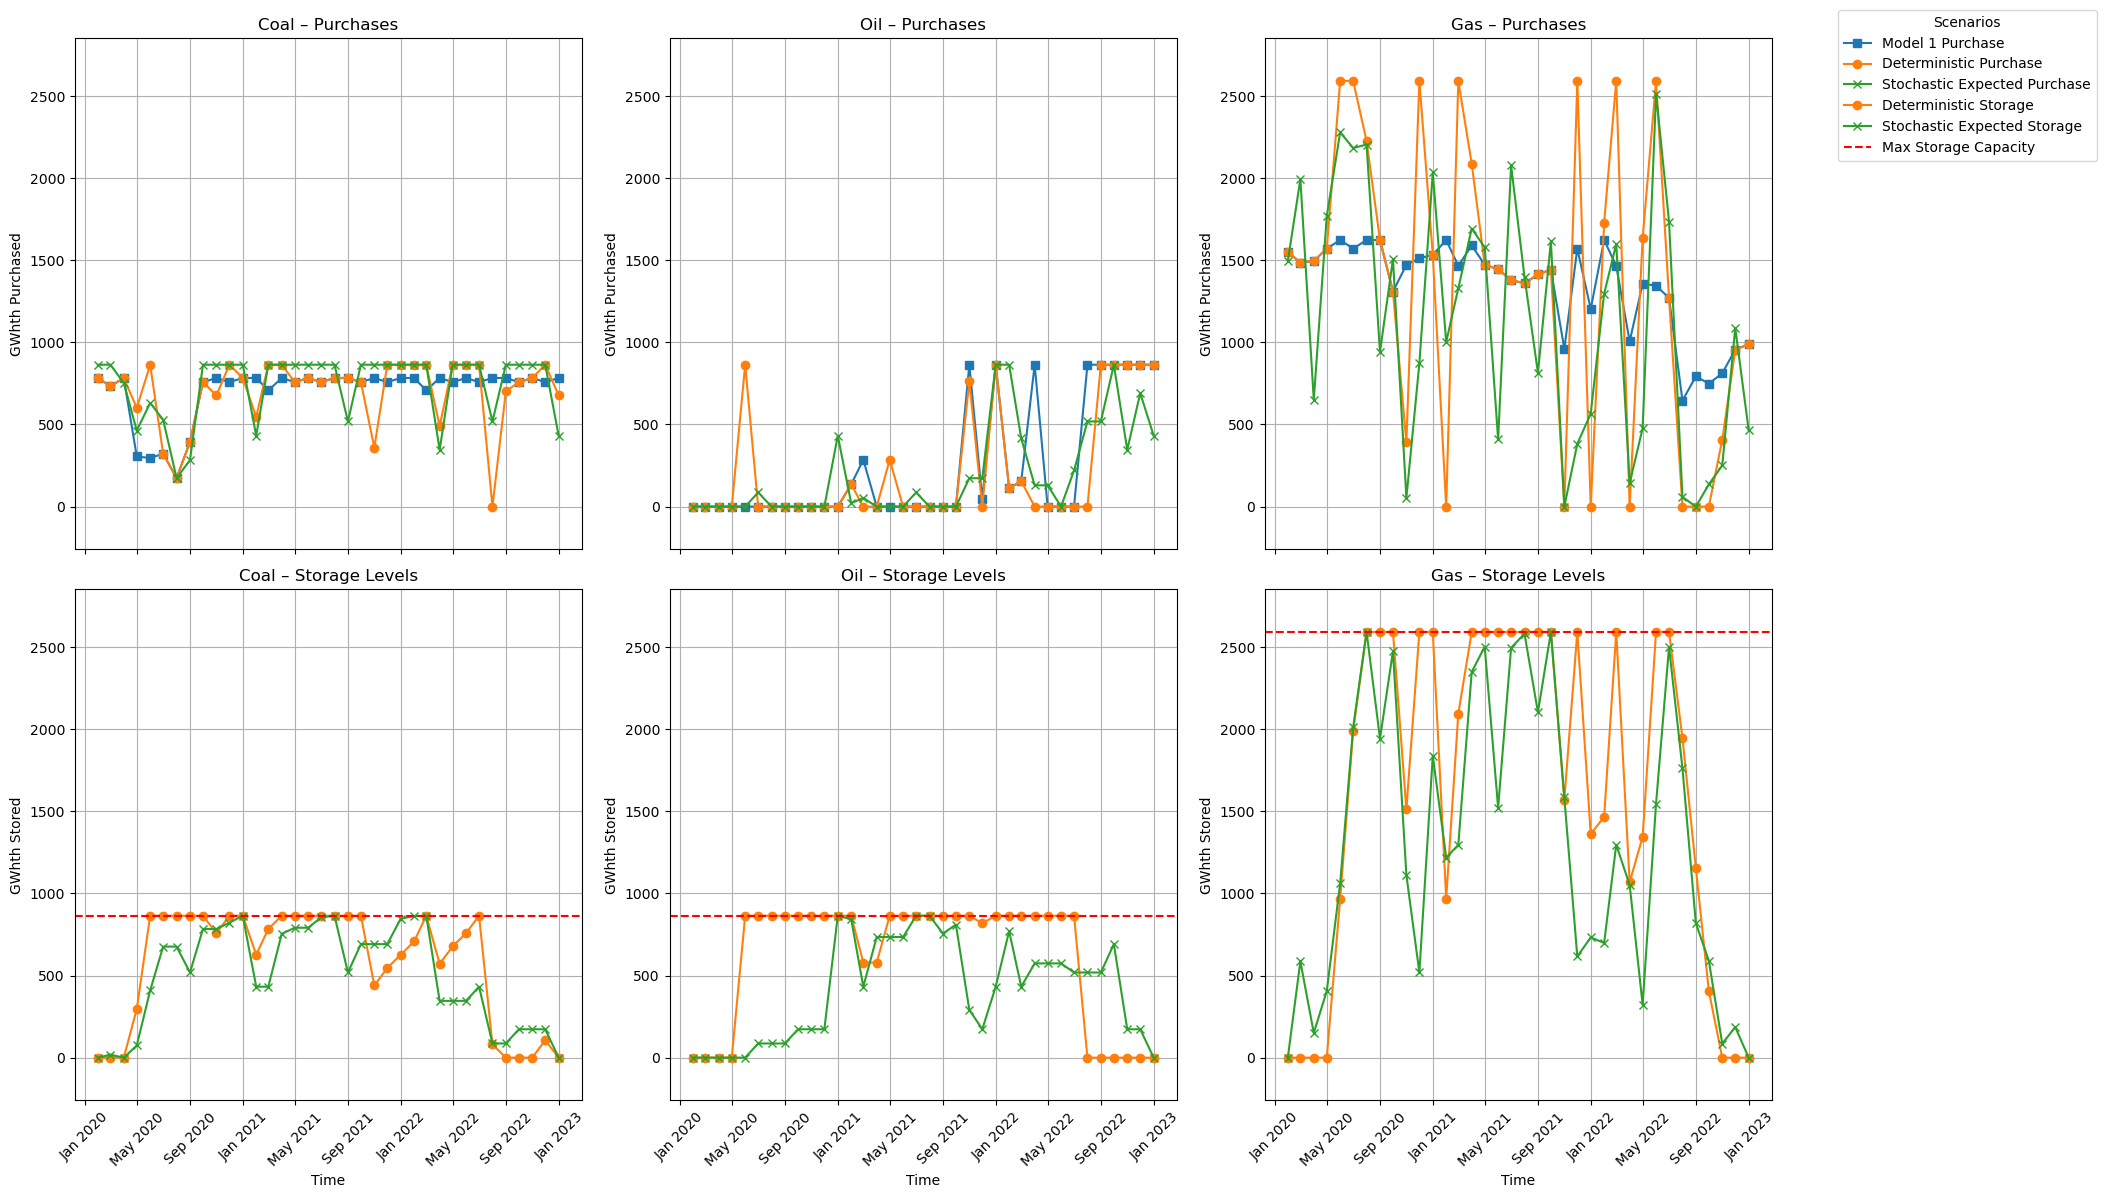

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

def plot_purchases_and_storage(base_df, det_df, exp_df, storage_mapped, F):

    # consistent colors
    colors = {
        "base": "tab:blue",
        "det": "tab:orange",
        "exp": "tab:green",
        "capacity": "red"
    }

    fig, axes = plt.subplots(2, len(F), figsize=(6 * len(F), 12), sharex='col')

    if len(F) == 1:
        axes = axes.reshape(2, 1)

    # ---------------------------------------------------
    # Compute global y-limits
    # ---------------------------------------------------
    purchase_values = []
    storage_values = []

    for f in F:
        purchase_values.extend(base_df[f"{f}_Bought"] / 1000)
        purchase_values.extend(det_df[f"{f}_Bought"] / 1000)
        purchase_values.extend(exp_df[f"{f}_Bought"] / 1000)

        storage_values.extend(det_df[f"{f}_Stored"] / 1000)
        storage_values.extend(exp_df[f"{f}_Stored"] / 1000)
        storage_values.append(storage_mapped[f] / 1000)

    min_purchase, max_purchase = np.min(purchase_values), np.max(purchase_values)
    min_storage, max_storage = np.min(storage_values), np.max(storage_values)

    purchase_padding = 0.1 * (max_purchase - min_purchase + 1e-9)
    storage_padding = 0.1 * (max_storage - min_storage + 1e-9)

    # Date formatting
    locator = mdates.AutoDateLocator()
    formatter = mdates.DateFormatter('%b %Y')

    # ---------------------------------------------------
    # PLOTTING
    # ---------------------------------------------------

    # to collect legend entries
    all_handles = []
    all_labels = []

    for col, f in enumerate(F):

        # === ROW 1: PURCHASES ===
        ax1 = axes[0, col]
        h1 = ax1.plot(base_df.index, base_df[f"{f}_Bought"] / 1000,
                 label="Model 1 Purchase", marker="s", color=colors["base"])
        h2 = ax1.plot(det_df.index, det_df[f"{f}_Bought"] / 1000,
                 label="Model 2 Purchase", marker="o", color=colors["det"])
        h3 = ax1.plot(exp_df.index, exp_df[f"{f}_Bought"] / 1000,
                 label="Model 3 Purchase", marker="x", color=colors["exp"])

        ax1.set_title(f"{f.capitalize()} – Purchases")
        ax1.set_ylabel("GWhth Purchased")
        ax1.grid(True)
        ax1.set_ylim(min_purchase - purchase_padding, max_purchase + purchase_padding)

        # === ROW 2: STORAGE ===
        ax2 = axes[1, col]
        h4 = ax2.plot(det_df.index, det_df[f"{f}_Stored"] / 1000,
                 label="Model 2 Storage", marker="o", color=colors["det"])
        h5 = ax2.plot(exp_df.index, exp_df[f"{f}_Stored"] / 1000,
                 label="Model 3 Storage", marker="x", color=colors["exp"])
        h6 = [ax2.axhline(storage_mapped[f] / 1000,
                    linestyle='--', color=colors["capacity"],
                    label="Max Storage Capacity")]

        ax2.set_title(f"{f.capitalize()} – Storage Levels")
        ax2.set_xlabel("Time")
        ax2.set_ylabel("GWhth Stored")
        ax2.grid(True)
        ax2.set_ylim(min_storage - storage_padding, max_storage + storage_padding)

        # Format x-axis dates
        for ax in (ax1, ax2):
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(formatter)
            ax.tick_params(axis='x', rotation=45)

        # ---------------------------------------------------
        # Create a clean legend with only 4 entries
        # ---------------------------------------------------

        # Pick handles from the last iteration of the loop (they exist for all fuels)
        model1_handle = h1[0]     # Model 1 purchase line
        model2_handle = h2[0]     # Model 2 purchase line
        model3_handle = h3[0]     # Model 3 purchase line
        capacity_handle = h6[0]   # storage capacity line

        final_handles = [model1_handle, model2_handle, model3_handle, capacity_handle]
        final_labels  = ["Model 1", "Model 2", "Model 3", "Max Capacity"]


    # ---------------------------------------------------
    # External legend on the left WITH frame
    # ---------------------------------------------------
    # fig.legend(
    #     final_handles,
    #     final_labels,
    #     loc='center left',
    #     bbox_to_anchor=(-0.20, 0.5),
    #     frameon=True,
    #     title="Scenarios"
    # )

    fig.legend(
        final_handles,
        final_labels,
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        frameon=True,
        title="Scenarios"
    )
    plt.tight_layout()
    
    plt.savefig(os.path.join(figures_path, "fuel_purchases_and_storage_levels.pdf"), bbox_inches='tight', dpi=300)
    plt.show()

plot_purchases_and_storage(base_df, det_df, exp_df, storage_mapped, F)